# STAC + VirtualiZarr

End-to-end example: query a STAC API for Sentinel COGs in California spanning
two adjacent UTM zones (10N and 11N), virtualize them into an Icechunk store
with zarr-datafusion-search metadata, and merge them into a single grid using
`merge(datafusion=True)`.

The UTM zone boundary runs roughly along **-120° longitude** through the
Sierra Nevada. We pick a bbox around Lake Tahoe that straddles both zones.


**AWS credentials:** This notebook reads from the public `e84-earth-search-sentinel-data` bucket
(requester-pays) in `us-west-2`. You need valid AWS credentials configured.

In [56]:
import warnings

import matplotlib.pyplot as plt
import xarray as xr
import zarr
from affine import Affine
from rasterix import RasterIndex

from lazymerge.merge import merge

warnings.filterwarnings("ignore")
xr.set_options(display_expand_indexes=True)

## 1. Configure cloud storage

Landsat Collection 2 Level-2 data lives in the `e84-earth-search-sentinel-dataset` S3 bucket
(requester-pays, `us-west-2`).

In [57]:
import boto3
from obspec_utils.registry import ObjectStoreRegistry
from obstore.auth.boto3 import Boto3CredentialProvider
from obstore.store import S3Store

scheme = "s3://"
bucket = "e84-earth-search-sentinel-data"
region = "us-west-2"

session = boto3.Session()
object_store = S3Store(
    bucket=bucket,
    region=region,
    request_payer=True,
    credential_provider=Boto3CredentialProvider(session=session),
)
registry = ObjectStoreRegistry({f"{scheme}{bucket}": object_store})

## 2. Set up Icechunk repository

Icechunk provides a versioned zarr store that supports virtual chunk references
back to the original COG files on S3.

In [58]:
import icechunk

location = "data/icechunk_california"
storage = icechunk.local_filesystem_storage(location)

config = icechunk.RepositoryConfig.default()
s3_chunk_store = icechunk.s3_store(
    region=region,
    requester_pays=True,
)
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(f"{scheme}{bucket}/", s3_chunk_store),
)
credentials = icechunk.containers_credentials(
    {f"{scheme}{bucket}/": icechunk.s3_credentials(from_env=True)},
)
repo = icechunk.Repository.open_or_create(
    storage=storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)
ic_session = repo.writable_session("main")

  2026-05-27T01:23:03.246051Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



## 3. Ingest STAC search results

Search Sentinel scenes and ingest the metadata with the `red`, `green`, and `blue` asset hrefs.

In [59]:
from zarr_datafusion_search import ingest_stac_search

rows = await ingest_stac_search(
    url="https://earth-search.aws.element84.com/v1",
    session=ic_session,
    bbox=(-121.5, 38.5, -118.5, 40.5),
    datetime="2025-10-01/2025-10-15",
    collections=["sentinel-2-c1-l2a"],
    max_items=10,
    asset_hrefs=["red", "green", "blue"],
    query={"eo:cloud_cover": {"lt": 10}},
)
rows

10

## 4. Query metadata with DataFusion

Use DataFusion SQL to inspect the ingested metadata and verify we have
scenes in both UTM zones.

In [61]:
from datafusion import SessionContext
from geodatafusion import register_all
from zarr_datafusion_search import ZarrTable

ic_session = repo.writable_session("main")
zarr_table = await ZarrTable.from_icechunk(session=ic_session, group_path="/meta")

ctx = SessionContext()
register_all(ctx)
ctx.register_table_provider("meta", zarr_table)

df = ctx.sql(
    "SELECT * FROM meta ORDER BY datetime",
)
df

asset_blue,asset_green,asset_red,bbox,constellation,created,datetime,earthsearch:payload_id,eo:cloud_cover,grid:code,id,mgrs:grid_square,mgrs:latitude_band,mgrs:utm_zone,platform,proj:epsg,s2:cloud_shadow_percentage,s2:datastrip_id,s2:datatake_id,s2:datatake_type,s2:degraded_msi_data_percentage,s2:generation_time,s2:high_proba_clouds_percentage,s2:medium_proba_clouds_percentage,s2:nodata_pixel_percentage,s2:not_vegetated_percentage,s2:processing_baseline,s2:product_type,s2:product_uri,s2:reflectance_conversion_factor,s2:saturated_defective_pixel_percentage,s2:snow_ice_percentage,s2:thin_cirrus_percentage,s2:tile_id,s2:unclassified_percentage,s2:vegetation_percentage,s2:water_percentage,storage:platform,storage:region,storage:requester_pays,updated,view:azimuth,view:incidence_angle,view:sun_azimuth,view:sun_elevation
https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B02.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B03.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/11/T/KE/2025/10/S2C_T11TKE_20251012T184845_L2A/B04.tif...,"b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00,\x9b9$\xb5\x1e^\xc0p\x0b\x96\xea\x02\xceC@\x99a\xa3\xac\xdf\xcd]\xc0p\x0b\x96\xea\x02\xceC@\x99a\xa3\xac\xdf\xcd]\xc0\xb8\x92\x1d\x1b\x81PD@,\x9b9$\xb5\x1e^\xc0\xb8\x92\x1d\x1b\x81PD@,\x9b9$\xb5\x1e^\xc0p\x0b\x96\xea\x02\xceC@'...",sentinel-2,2025-10-13 00:15:55.321002025-10-13 00:15:55.321000...,2025-10-12 18:53:34.825002025-10-12 18:53:34.825000...,roda-sentinel-2-c1-l2a/woroda-sentinel-2-c1-l2a/workflow-sentinel-2-c1-l2a-to-stac/ecfd606cb24393f5cbc65f4488dcf185...,0.234831,MGRS-11TKE,S2C_T11TKE_20251012T18484S2C_T11TKE_20251012T184845_L2A...,KE,T,11,sentinel-2c,32611,0.003685,S2C_OPER_MSI_L2A_DS_2CPS_S2C_OPER_MSI_L2A_DS_2CPS_20251012T220220_S20251012T184845_N05.11...,GS2C_20251012T184341_0057GS2C_20251012T184341_005760_N05.11...,INS-NOBS,0.0134,2025-10-12T22:02:20.000002025-10-12T22:02:20.000000Z...,0.049996,0.106056,14.551552,90.295559,05.11,S2MSI2A,S2C_MSIL2A_20251012T18434S2C_MSIL2A_20251012T184341_N0511_R070_T11TKE_20251012T220220.SAFE...,1.00270392241554,0,3.5e-05,0.078779,S2C_OPER_MSI_L2A_TL_2CPS_S2C_OPER_MSI_L2A_TL_2CPS_20251012T220220_A005760_T11TKE_N05.11...,0.044552,4.145623,4.957866,AWS,us-west-2,False,2025-10-13 00:15:55.321002025-10-13 00:15:55.321000...,103.39706481599862,8.226388589336729,162.817826061657,40.6701397768753
https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B02.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B03.tif...,https://e84-earth-search-https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/10/T/GK/2025/10/S2C_T10TGK_20251012T184845_L2A/B04.tif...,b'\x01\x03\x00\x00\x00\x0b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\xf2z0)>\x1e^\xc0\x93nK\xe4\x82\xcdC@\xf3!\xa8\x1a\xbd\xd5]\xc0\x93nK\xe4\x82\xcdC@\xf3!\xa8\x1a\xbd\xd5]\xc0\x03|\xb7y\xe3ND@\xf2z0)>\x1e^\xc0\x03|\xb7y\xe3ND@\xf2z0)>\x1e^\xc0\x93nK\xe4\x82\xcdC@'...,sentinel-2,2025-10-13 00:48:17.423002025-10-13 00:48:17.423000...,2025-10-12 18:53:35.190002025-10-12 18:53:35.190000...,roda-sentinel-2-c1-l2a/woroda-sentinel-2-c1-l2a/workflow-sentinel-2-c1-l2a-to-stac/fefe140d53c1552182fb4a0dcdae9773...,0.279838,MGRS-10TGK,S2C_T10TGK_20251012T18484S2C_T10TGK_20251012T184845_L2A...,GK,T,10,sentinel-2c,32610,0.003699,S2C_OPER_MSI_L2A_DS_2CPS_S2C_OPER_MSI_L2A_DS_2CPS_20251012T220220_S20251012T184845_N05.11...,GS2C_20251012T184341_0057GS2C_20251012T184341_005760_N05.11...,INS-NOBS,0.0143,2025-10-12T22:02:20.00

## 5. Virtualize COGs and write conventions

For each scene, use VirtualiZarr to create virtual zarr references to the
original COG overviews on S3, then write zarr conventions metadata
(multiscales, spatial, proj) to the Icechunk store.

In [63]:
from collections.abc import MutableMapping
from typing import Any
from urllib.parse import urlparse

from rasterio.warp import transform_bounds
from shapely import wkb
from virtual_tiff import VirtualTIFF
from virtualizarr import open_virtual_dataset

from lazymerge.conventions import ProjAttrs, SpatialAttrs, write_proj, write_spatial


def write_multiscales(overviews: int, attrs: MutableMapping[str, Any]) -> None:
    layout = []
    factor = 2
    for overview in range(overviews):
        if overview == 0:
            config = {"asset": str(overview)}
        else:
            scale = float(factor**overview)
            config = {
                "asset": str(overview),
                "derived_from": str(overview - 1),
                "factors": [factor, factor],
                "transform": {
                    "scale": [scale, scale],
                    "translation": [0.0, 0.0],
                },
            }
        layout.append(config)
    attrs["multiscales"] = {"layout": layout}


def compute_transform_from_bbox(
    projected_bbox: tuple[float, float, float, float],
    shape: tuple[int, int],
) -> tuple[float, float, float, float, float, float]:
    """Compute an affine transform from a projected bounding box and array shape.

    Follows the north-up raster convention (y decreasing top-to-bottom),
    similar to lazycogs' compute_output_grid.
    """
    minx, miny, maxx, maxy = projected_bbox
    height, width = shape
    res_x = (maxx - minx) / width
    res_y = -(maxy - miny) / height
    return (res_x, 0.0, minx, 0.0, res_y, maxy)


def get_base_shape(
    row: dict[str, Any],
    store: Any,
    bands: list[str],
) -> tuple[int, int]:
    """Get array shape from the row, falling back to the virtualized overview 0 array."""
    if "shape_y" in row and row["shape_y"] is not None:
        return (row["shape_y"], row["shape_x"])
    # Read shape from the already-written VirtualiZarr array (overview 0)
    item_id = row["id"]
    level_group = zarr.open_group(store, path=f"/{item_id}/{bands[0]}/0", zarr_format=3)
    for _name, member in level_group.members():
        if isinstance(member, zarr.Array):
            return member.shape
    msg = f"No array found at /{item_id}/{bands[0]}/0"
    raise ValueError(msg)


def get_base_transform(
    row: dict[str, Any],
    projected_bbox: tuple[float, float, float, float],
    shape: tuple[int, int],
) -> tuple[float, float, float, float, float, float]:
    """Get the affine transform from the row, falling back to bbox/shape calculation."""
    if "transform_0" in row and row["transform_0"] is not None:
        return (
            row["transform_0"],
            row["transform_1"],
            row["transform_2"],
            row["transform_3"],
            row["transform_4"],
            row["transform_5"],
        )
    return compute_transform_from_bbox(projected_bbox, shape)


def https_to_s3(url: str) -> str:
    parsed = urlparse(url)
    bucket = parsed.hostname.split(".s3.")[0]
    key = parsed.path.lstrip("/")
    return f"s3://{bucket}/{key}"


def write_virtualizarr_data(
    id: str,
    assets: dict[str, str],
    overviews: int,
    session,
    registry,
) -> None:
    for key, asset in assets.items():
        for overview in range(overviews):
            group = f"{id}/{key}/{overview}"
            asset_s3 = https_to_s3(asset)
            ds = open_virtual_dataset(
                url=asset_s3,
                registry=registry,
                parser=VirtualTIFF(ifd=overview),
            )
            ds.vz.to_icechunk(store=session.store, group=group)


def write_conventions(row: dict[str, Any], overviews: int, session, bands: list[str]) -> None:
    store = session.store
    item_id = row["id"]

    # Compute projected bbox once (same for all overviews)
    geom = wkb.loads(row["bbox"])
    bbox_4326 = [*geom.bounds]
    proj_code = row["proj:epsg"]
    projected_bbox = transform_bounds("EPSG:4326", proj_code, *bbox_4326)

    # Use shape from metadata if available, otherwise read from virtualized array
    base_shape = get_base_shape(row, store, bands)

    # Use transform from metadata if available, otherwise derive from bbox + shape
    base_transform = get_base_transform(row, projected_bbox, base_shape)

    proj_attrs = ProjAttrs(code=f"EPSG:{proj_code}")

    # Write spatial+proj on the item group (for source discovery)
    item_group = zarr.open_group(store, path=f"/{item_id}", zarr_format=3)
    write_spatial(
        item_group,
        SpatialAttrs(
            dimensions=["y", "x"],
            transform=base_transform,
            bbox=projected_bbox,
            shape=base_shape,
        ),
    )
    write_proj(item_group, proj_attrs)

    for band in bands:
        # Write multiscales convention on each band group
        band_group = zarr.open_group(store, path=f"/{item_id}/{band}", zarr_format=3)
        write_multiscales(overviews=overviews, attrs=band_group.attrs)

        # Write spatial+proj on each overview array
        for level in range(overviews):
            factor = 2**level
            ovr_res_x = base_transform[0] * factor
            ovr_res_y = base_transform[4] * factor
            ovr_transform = (
                ovr_res_x,
                base_transform[1],
                base_transform[2],
                base_transform[3],
                ovr_res_y,
                base_transform[5],
            )

            # Open the VirtualiZarr array (group-wrapped: {level}/{level})
            level_group = zarr.open_group(
                store,
                path=f"/{item_id}/{band}/{level}",
                zarr_format=3,
            )
            for _name, member in level_group.members():
                if isinstance(member, zarr.Array):
                    arr = member
                    break
            else:
                continue

            ovr_shape = arr.shape
            write_spatial(
                arr,
                SpatialAttrs(
                    dimensions=["y", "x"],
                    transform=ovr_transform,
                    bbox=projected_bbox,
                    shape=ovr_shape,
                ),
            )
            write_proj(arr, proj_attrs)

In [64]:
overviews = 5
bands = ["red", "green", "blue"]

for row in df.to_arrow_table().to_pylist():
    assets = {
        "red": row["asset_red"],
        "green": row["asset_green"],
        "blue": row["asset_blue"],
    }
    ic_session = repo.writable_session("main")
    write_virtualizarr_data(
        id=row["id"],
        assets=assets,
        overviews=overviews,
        session=ic_session,
        registry=registry,
    )
    write_conventions(row=row, overviews=overviews, session=ic_session, bands=bands)
    message = ic_session.commit(row["id"])

## 6. Inspect the store

Verify the Icechunk store has the expected structure: `/meta` group with
columnar arrays, plus per-scene groups with band subgroups and overviews.

In [65]:
ic_session = repo.writable_session("main")
root = zarr.open(ic_session.store)
root.tree()

/
├── S2C_T10SFH_20251012T184845_L2A
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   └── red
│       ├── 0
│       │   └── 0 (10980, 10980) uint16
│       ├── 1
│       │   └── 1 (5490, 5490) uint16
│       ├── 2
│       │   └── 2 (2745, 2745) uint16
│       ├── 3
│       │   └── 3 (1373, 1373) uint16
│       └── 4
│           └── 4 (687, 687) uint16
├── S2C_T10SFJ_20251012T184845_L2A
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   └── red
│       ├── 0
│       │   └── 0 (10980, 10980) uint16
│       ├── 1
│       │   └── 1 (5490, 5490) uint16
│       ├── 2
│       │   └── 2 (2745, 2745) uint16
│       ├── 3
│       │   └── 3 (1373, 1373) uint16
│       └── 4
│           └── 4 (687, 687) uint16
├── S2C_T10SGH_20251012T184845_L2A
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   └── red
│       ├── 0
│       │   └── 0 (10980, 10980) uint16
│       ├── 1
│       │   └── 1 (5490, 5490) uint16
│       ├── 2
│       │   └── 2 (2745, 2745) uint16
│       ├── 3
│       │   └── 3 (1373, 1373) uint16
│       └── 4
│           └── 4 (687, 687) uint16
├── S2C_T10SGJ_20251012T184845_L2A
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   └── red
│       ├── 0
│       │   └── 0 (10980, 10980) uint16
│       ├── 1
│       │   └── 1 (5490, 5490) uint16
│       ├── 2
│       │   └── 2 (2745, 2745) uint16
│       ├── 3
│       │   └── 3 (1373, 1373) uint16
│       └── 4
│           └── 4 (687, 687) uint16
├── S2C_T10TGK_20251012T184845_L2A
│   ├── blue
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16
│   ├── green
│   │   ├── 0
│   │   │   └── 0 (10980, 10980) uint16
│   │   ├── 1
│   │   │   └── 1 (5490, 5490) uint16
│   │   ├── 2
│   │   │   └── 2 (2745, 2745) uint16
│   │   ├── 3
│   │   │   └── 3 (1373, 1373) uint16
│   │   └── 4
│   │       └── 4 (687, 687) uint16


## 7. Lazy merge

Define a target grid in **UTM 11N** (EPSG:32611) covering the Lake Tahoe area.
Sources in UTM 10N will be reprojected on the fly during merge.

We use sortby="id"` to control compositing order.

In [66]:
bands = ["red", "green", "blue"]
result_arr, result_spatial, result_proj, time_coords = merge(
    store=ic_session.store,
    crs="EPSG:32611",
    bbox=(200000.0, 4260000.0, 340000.0, 4490000.0),
    resolution=20.0,
    chunk_size=(1024, 1024),
    bands=bands,
    datafusion=True,
    sortby="datetime",
    temporal_grouping="P1D",
    nodata=0,
)
result_arr

,Array,Chunk
Bytes,966.0 MB,4.2 MB
Shape,"(1, 3, 11500, 7000)","(1, 1, 1024, 1024)"
Count,3 arrays in Plan,252 Chunks
Type,float32,np.ndarray


## 8. Open the lazy Cubed array with xarray

In [67]:
da = xr.DataArray(result_arr, dims=["time", "bands", "y", "x"])

affine = Affine(*result_spatial.transform)
raster_idx = RasterIndex.from_transform(
    affine=affine,
    width=da.sizes["x"],
    height=da.sizes["y"],
    x_dim="x",
    y_dim="y",
    crs=result_proj.code,
)
coords = xr.Coordinates.from_xindex(raster_idx)
da = da.assign_coords(coords)
da = da.proj.assign_crs(spatial_ref=result_proj.code, allow_override=True)
da = da.assign_coords({"time": time_coords, "bands": bands})
da

,Array,Chunk
Bytes,966.0 MB,4.2 MB
Shape,"(1, 3, 11500, 7000)","(1, 1, 1024, 1024)"
Count,3 arrays in Plan,252 Chunks
Type,float32,np.ndarray


## 9. Compute and visualize

Compute to materialize the array and then plot it.

In [68]:
da = da.compute()
da

<xarray.DataArray 'array-020' (time: 1, bands: 3, y: 11500, x: 7000)> Size: 966MB
array([[[[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1271., 1211., 1138., ..., 2332., 2362., 2062.],
         [1505., 1561., 1194., ..., 1794., 1809., 1902.],
         [1490., 1418., 1238., ..., 2128., 2092., 1834.]],

        [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1393., 1301., 1160., ..., 2246., 2180., 1974.],
         [1512., 1540., 1304., ..., 1832., 1746., 1852.],
         [1504., 1386., 1297., ..., 2018., 1966., 1787.]],

        [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         [  nan,   nan,   nan, ...,   nan,   nan,   nan],
         ...,
         [1112., 1102., 1045., ..., 1905., 1935., 1750.],
         [1225., 1232., 1081., ..., 1567., 1631., 1644.],
         [1244., 1186., 1086., ..., 1740., 1700., 1578.]]]],
      shape=(1, 3, 11500, 7000), dtype=float32)
Coordinates:
  * time         (time) datetime64[s] 8B 2025-10-12
  * bands        (bands) <U5 60B 'red' 'green' 'blue'
  * y            (y) float64 92kB 4.49e+06 4.49e+06 ... 4.26e+06 4.26e+06
  * x            (x) float64 56kB 2e+05 2e+05 2e+05 ... 3.4e+05 3.4e+05 3.4e+05
  * spatial_ref  int64 8B 0
Indexes:
  ┌ x            RasterIndex (crs=EPSG:32611)
  └ y
    spatial_ref  CRSIndex (crs=EPSG:32611)

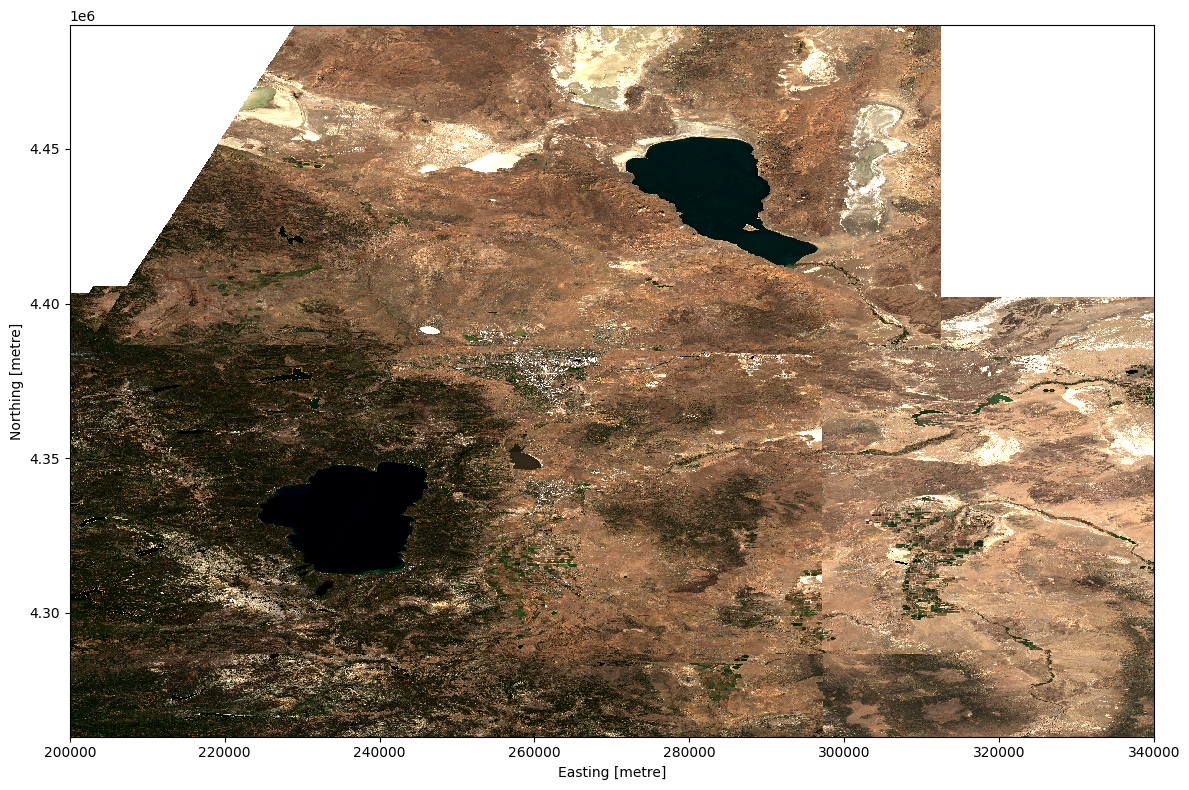

In [52]:
da = da.sel(time="2025-10-12")
da.plot.imshow(rgb="bands", robust=True, figsize=(12, 8))
plt.title("")
plt.tight_layout();